<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula22a_regress%C3%A3o_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

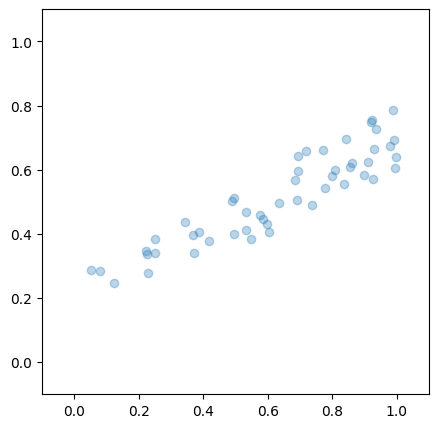

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=50, splope=0.5, intercept=0.2):
  X = np.random.uniform(size=(n,1))
  noise = (np.random.random(size=(n,1)) - 0.5) * 0.2
  y = splope * X + intercept + noise
  return X, y.flatten()

def plotDataset(X, y):
  plt.plot(X, y, 'o', alpha=0.3)
  plt.xlim(-0.1, 1.1)
  plt.ylim(-0.1, 1.1)

X, y = createDataset()
plt.figure(figsize=(5,5))
plotDataset(X, y)
plt.show()

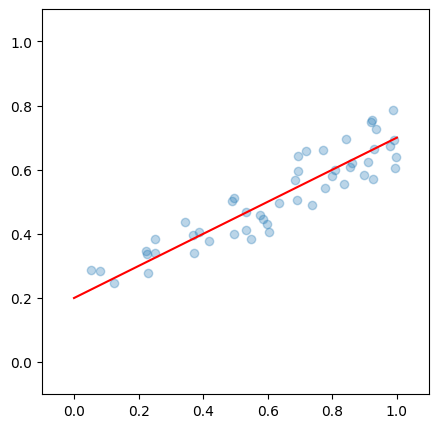

In [7]:
def plotLine(coef, bias, color='r'):
  x = np.array([0, 1])
  y = coef * x + bias
  plt.plot(x, y, color)

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotLine(0.5, 0.2)
plt.show()

MSE: 0.003167177326110321
Weights: [0.47455371]
Bias: 0.21563299034104164


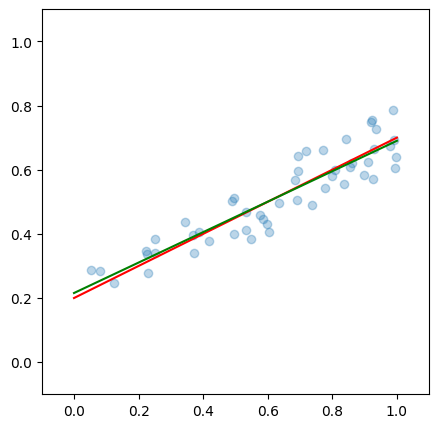

In [19]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import mean_squared_error

def sign(a):
  return (a>0)*2-1

class LinearRegression(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=1000, learning_rate=0.01):
    self.max_iter = max_iter
    self.learning_rate = learning_rate

  def fit(self, X, y):
    self.w = np.random.uniform(size=(X.shape[1],))
    self.b = np.random.uniform()
    # Widrow-Hoff
    for _ in range(self.max_iter):
      y_pred = self.pre_activation(X)
      error = y - y_pred
      self.w += X.T@error * self.learning_rate
      self.b += np.sum(error) * self.learning_rate
    return self

  def pre_activation(self, X):
    logits = X@self.w + self.b
    return logits

  def predict(self, X):
    logits = self.pre_activation(X)
    y_pred = logits #sign(logits)
    return y_pred

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
print(f"MSE: {mean_squared_error(y, y_pred)}")
print(f"Weights: {model.w}")
print(f"Bias: {model.b}")

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotLine(0.5, 0.2)
plotLine(model.w[0], model.b, 'g')
plt.show()